In [16]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

ROOT = "../outputs/"  # <-- change to your unzipped output folder
N_BATCHES = 8

plt.rcParams["figure.dpi"] = 110

def load_all(subdir, root=ROOT, n_batches=N_BATCHES):
    """Load and concat every part-*.csv under batch_i/<subdir>/."""
    frames = []
    for i in range(n_batches):
        pattern = os.path.join(root, f"batch_{i}", subdir, "part-*.csv")
        for f in glob.glob(pattern):
            df = pd.read_csv(f)
            df["batch"] = i
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

def load_daily_trend(root=ROOT):
    pattern = os.path.join(root, "daily_trend", "part-*.csv")
    frames = [pd.read_csv(f) for f in glob.glob(pattern)]
    df = pd.concat(frames, ignore_index=True)
    df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
    return df.sort_values("FL_DATE")

# Which airlines have the highest delay rate on average?


Airline delay rates:
    OP_UNIQUE_CARRIER  total_flights  delayed_flights  delay_rate
5                 F9          13285             4505       33.91
9                 NK          21876             6209       28.38
6                 G4           8615             2412       28.00
3                 B6          23249             6084       26.17
12                UA          56657            12965       22.88
8                 MQ          18849             4274       22.67
1                 AA          74999            16691       22.25
11                OO          50347            11170       22.19
7                 HA           6697             1473       21.99
0                 9E          16926             3574       21.12
2                 AS          19801             4111       20.76
4                 DL          75174            15242       20.28
13                WN         112430            21830       19.42
14                YX          24476             3953       16.15
10

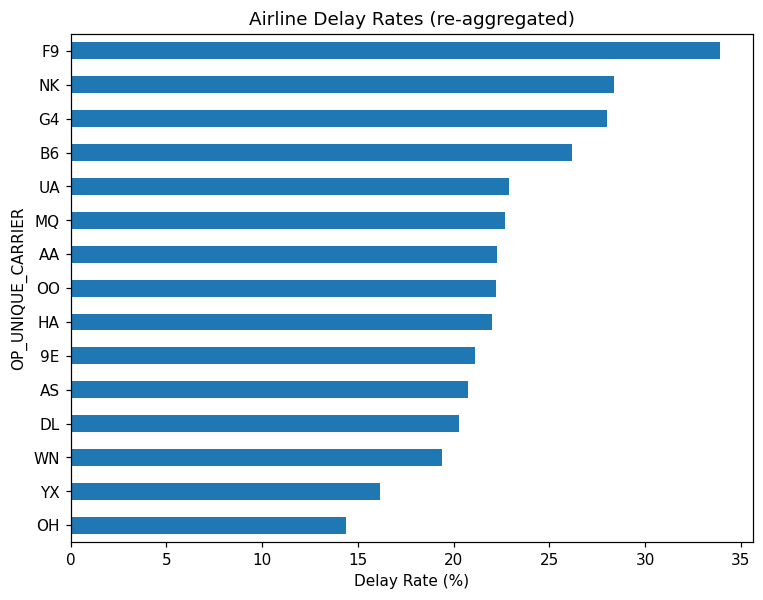

In [ ]:
# Airline delay rates
airline = load_all("airline_delays")
airline_agg = (
    airline.groupby("OP_UNIQUE_CARRIER")
    .agg(total_flights=("total_flights", "sum"), delayed_flights=("delayed_flights", "sum"))
    .reset_index()
)
airline_agg["delay_rate"] = (airline_agg["delayed_flights"] / airline_agg["total_flights"] * 100).round(2)
airline_agg = airline_agg.sort_values("delay_rate", ascending=False)
print("\nAirline delay rates:\n", airline_agg)

airline_agg.plot.barh(x="OP_UNIQUE_CARRIER", y="delay_rate", figsize=(8, 6), legend=False)
plt.gca().invert_yaxis()
plt.xlabel("Delay Rate (%)")
plt.title("Airline Delay Rates (re-aggregated)")
plt.show()

Which airports have the highest delay rate on average?

In [ ]:
# Airport delay rates (filter to >= 500 flights)
airport = load_all("airport_delays")
airport_agg = (
    airport.groupby(["ORIGIN", "ORIGIN_CITY_NAME"])
    .agg(total_flights=("total_flights", "sum"), delayed_flights=("delayed_flights", "sum"))
    .reset_index()
)
airport_agg["delay_rate"] = (airport_agg["delayed_flights"] / airport_agg["total_flights"] * 100).round(2)
airport_qual = airport_agg[airport_agg["total_flights"] >= 500].sort_values("delay_rate", ascending=False)

print(f"\nQualifying airports (>=500 flights): {len(airport_qual)} of {len(airport_agg)}")
print("\nTop 10 highest:\n", airport_qual.head(10))
print("\nTop 10 lowest:\n", airport_qual.tail(10))


Qualifying airports (>=500 flights): 121 of 339

Top 10 highest:
     ORIGIN     ORIGIN_CITY_NAME  total_flights  delayed_flights  delay_rate
162    JAC          Jackson, WY            510              212       41.57
99     EGE            Eagle, CO            511              187       36.59
17     ASE            Aspen, CO            887              312       35.17
117    FSD      Sioux Falls, SD            571              179       31.35
88     DEN           Denver, CO          22460             6703       29.84
239    PGD      Punta Gorda, FL            552              162       29.35
114    FLL  Fort Lauderdale, FL           7600             2204       29.00
109    FAR            Fargo, ND            563              162       28.77
54     BZN          Bozeman, MT            821              232       28.26
229    ORD          Chicago, IL          20086             5639       28.07

Top 10 lowest:
     ORIGIN       ORIGIN_CITY_NAME  total_flights  delayed_flights  delay_rate
13

# What times of day do airports have the worst delays?


Hourly delay rates:
     departure_hour  total_flights  delay_rate
5                5        14212.0    0.134033
6                6        39486.0    0.131282
7                7        35196.0    0.163444
8                8        36285.0    0.170224
9                9        30974.0    0.184371
10              10        33715.0    0.189110
11              11        34170.0    0.202170
12              12        33062.0    0.212549
13              13        32794.0    0.231057
14              14        31009.0    0.236695
15              15        30956.0    0.240874
16              16        31980.0    0.253341
17              17        32619.0    0.261343
18              18        32746.0    0.269688
19              19        29924.0    0.277215
20              20        23139.0    0.275499
21              21        18939.0    0.258675
22              22        11797.0    0.246479
23              23         4549.0    0.219057


C:\Users\gclou\AppData\Local\Temp\ipykernel_8372\3737023242.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


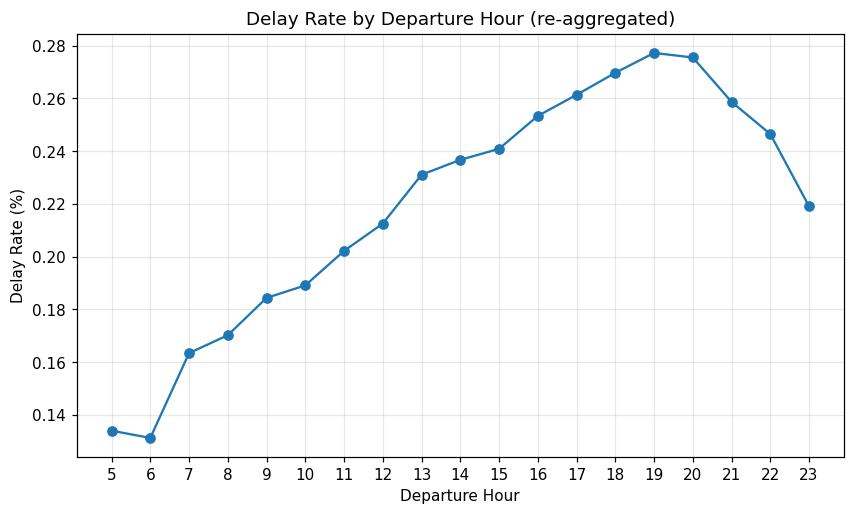

In [22]:
# Hourly delay rates
hourly = load_all("hourly_delays")
hourly_agg = (
    hourly.groupby("departure_hour")
    .apply(lambda g: pd.Series({
        "total_flights": g["total_flights"].sum(),
        # weighted average delay rate by flight volume
        "delay_rate": (g["delay_rate"] * g["total_flights"]).sum() / g["total_flights"].sum(),
    }))
    .reset_index()
    .sort_values("departure_hour")
)

# Exclude hours 0-4: very low flight volume
hourly_agg = hourly_agg[hourly_agg["departure_hour"] >= 5]

print("\nHourly delay rates:\n", hourly_agg)

plt.figure(figsize=(9, 5))
plt.plot(hourly_agg["departure_hour"], hourly_agg["delay_rate"], marker="o")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Departure Hour (re-aggregated)")
plt.xticks(hourly_agg["departure_hour"])
plt.grid(alpha=0.3)
plt.show()

# What days of the month have the highest or lowest delay rates?


Daily trend (head):
       FL_DATE  total_flights  delayed_flights  delay_rate
28 2023-01-01          15856             4018       25.34
30 2023-01-02          18075             6822       37.74
29 2023-01-03          17683             6559       37.09
31 2023-01-04          16989             5664       33.34
32 2023-01-05           6397             1610       25.17

Min delay rate: 8.34% on 2023-01-09
Max delay rate: 57.20% on 2023-01-11


C:\Users\gclou\AppData\Local\Temp\ipykernel_8372\3014247179.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])


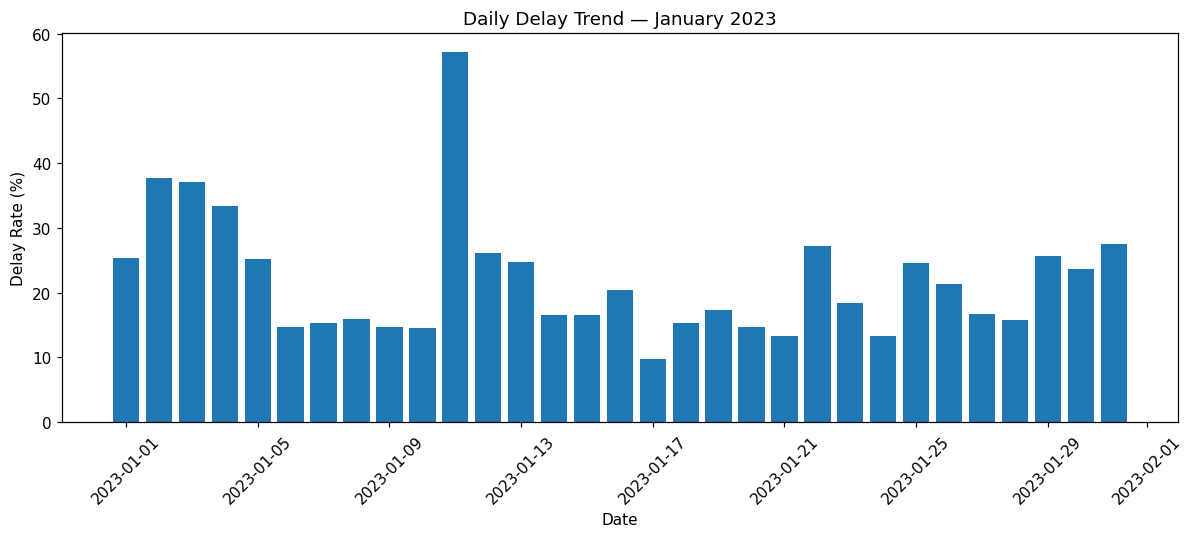

In [ ]:
# Daily trend
daily = load_daily_trend()
print("\nDaily trend (head):\n", daily.head())
print(f"\nMin delay rate: {daily['delay_rate'].min():.2f}% on {daily.loc[daily['delay_rate'].idxmin(), 'FL_DATE'].date()}")
print(f"Max delay rate: {daily['delay_rate'].max():.2f}% on {daily.loc[daily['delay_rate'].idxmax(), 'FL_DATE'].date()}")

plt.figure(figsize=(11, 5))
plt.bar(daily["FL_DATE"], daily["delay_rate"])
plt.xlabel("Date")
plt.ylabel("Delay Rate (%)")
plt.title("Daily Delay Trend — January 2023")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()